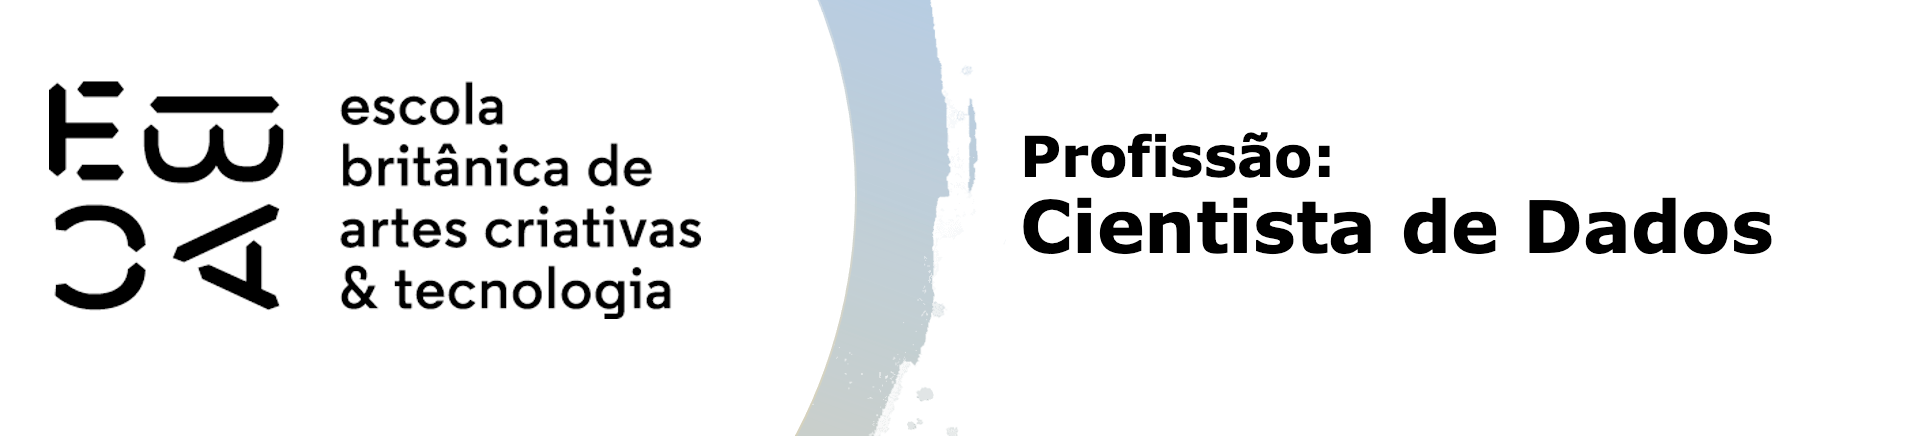

# Tarefa I

Neste projeto, estamos construindo um credit scoring para cartão de crédito, em um desenho amostral com 15 safras, e utilizando 12 meses de performance.

Carregue a base de dados ```credit_scoring.ftr```.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import silhouette_score

df = pd.read_feather('../Mod_35/credit_scoring.ftr')
df.head()

,data_ref,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda,mau
0,2015-01-01,5733,F,N,N,0,Empresário,Médio,Solteiro,Casa,43,6.873973,1.0,2515.39,False
1,2015-01-01,727,F,S,S,0,Assalariado,Médio,Casado,Casa,35,4.526027,2.0,3180.19,False
2,2015-01-01,6374,F,N,N,2,Assalariado,Médio,Casado,Casa,31,0.243836,4.0,1582.29,False
3,2015-01-01,9566,F,N,N,0,Assalariado,Médio,Casado,Casa,54,12.772603,2.0,13721.17,False
4,2015-01-01,9502,F,S,N,0,Assalariado,Superior incompleto,Solteiro,Casa,31,8.432877,1.0,2891.08,False


## Amostragem

Separe os três últimos meses como safras de validação *out of time* (oot).

Variáveis:<br>
Considere que a variável ```data_ref``` não é uma variável explicativa, é somente uma variável indicadora da safra, e não deve ser utilizada na modelagem. A variávei ```index``` é um identificador do cliente, e também não deve ser utilizada como covariável (variável explicativa). As restantes podem ser utilizadas para prever a inadimplência, incluindo a renda.


In [2]:
data = df[df['data_ref'].dt.year == 2015].copy()
data_unseen = df[df['data_ref'].dt.year == 2016].copy()

print(f'Dimensões dos dados para treino do modelo: {data.shape}\nDimensões dos dados para validação do modelo (OOT): {data_unseen.shape}')

Dimensões dos dados para treino do modelo: (600000, 15)
Dimensões dos dados para validação do modelo (OOT): (150000, 15)


## Descritiva básica univariada

- Descreva a base quanto ao número de linhas, número de linhas para cada mês em ```data_ref```.
- Faça uma descritiva básica univariada de cada variável. Considere as naturezas diferentes: qualitativas e quantitativas.

In [3]:
# Classificar variáveis em qualitativas (discretas) e quantitativas (contínuas)
def classificar_variavel(variavel: pd.Series) -> str:
    '''
    Função para classificar uma variável em 'discreta' ou 'contínua'.

    Parâmetros:
    - variavel: recebe uma Serie do Pandas

    Retorna:
    - string identificando a variável
    '''
    try:
        num_classes = variavel.nunique()
        dtype = variavel.dtype
        if num_classes >= 6 and dtype in ['int64', 'float64']:
            return 'contínua'
        else:
            return 'discreta'
    except:
        return 'não identificado'
        

In [4]:
# Criando tabela com metadados
metadata = pd.DataFrame({'dtype': data.dtypes,
                         'num_missings': data.isna().sum(),
                         'num_classes': data.nunique(),
                         'tipo_variavel': [classificar_variavel(data[col]) for col in data],
                         'papel': 'independente'})

# Identificando variáveis que não utilizaremos
metadata.loc[metadata.index == 'data_ref', 'papel'] = 'não usar'
metadata.loc[metadata.index == 'index', 'papel'] = 'não usar'

# Identificando variável dependente
metadata.loc[metadata.index == 'mau', 'papel'] = 'dependente'

# Visualizando resultado
metadata

,dtype,num_missings,num_classes,tipo_variavel,papel
data_ref,datetime64[ns],0,12,discreta,não usar
index,int64,0,16650,contínua,não usar
sexo,object,0,2,discreta,independente
posse_de_veiculo,object,0,2,discreta,independente
posse_de_imovel,object,0,2,discreta,independente
qtd_filhos,int64,0,8,contínua,independente
tipo_renda,object,0,5,discreta,independente
educacao,object,0,5,discreta,independente
estado_civil,object,0,5,discreta,independente
tipo_residencia,object,0,6,discreta,independente


In [5]:
# Visualizando quantidade de registros por mês nos dados
data.groupby(by='data_ref', observed=False)['data_ref'].count()

data_ref
2015-01-01    50000
2015-02-01    50000
2015-03-01    50000
2015-04-01    50000
2015-05-01    50000
2015-06-01    50000
2015-07-01    50000
2015-08-01    50000
2015-09-01    50000
2015-10-01    50000
2015-11-01    50000
2015-12-01    50000
Name: data_ref, dtype: int64

In [6]:
# Definindo funções para conduzir análise univariada
def analise_univariada_quantitativa(variavel: pd.Series) -> None:
    '''
    Função para plotar a análise univariada de uma variável contínua.

    Parâmetros:
    - variavel: recebe o Series do Pandas da variável em questão
    '''
    tb = pd.DataFrame(variavel.describe().rename({'count': 'contagem', 'mean': 'média', 'std': 'desvio padrão'}))
    display(tb)

    variavel.plot(kind='hist', ylabel='Frequência', title='Histograma de {}'.format(variavel.name.capitalize()))
    plt.show()

def analise_univariada_qualitativa(variavel: pd.Series) -> None:
    '''
    Função para plotar a análise univariada de uma variável discreta.

    Parâmetros:
    - variavel: recebe o Series do Pandas da variável em questão
    '''
    tb = pd.DataFrame(variavel.value_counts(normalize=True)).rename({'proportion': 'Proporção'}, axis=1)
    display(tb)

    tb.plot(kind='bar', title='Proporção das Classes de {}'.format(variavel.name.capitalize()))
    plt.show()

def analise_univariada(variavel: pd.Series, tipo: str) -> None:
    '''
    Função para conduzir a análise univariada de acordo com o tipo da variável.

    
    Parâmetros:
    - variavel: recebe o Series do Pandas da variável em questão.
    - tipo: recebe o tipo da variável, entre 'discreta' e 'contínua'.
    '''
    if tipo not in ['discreta', 'contínua']:
        return 'Tipo da variável não aceito'
    if tipo == 'discreta':
        return analise_univariada_qualitativa(variavel)
    return analise_univariada_quantitativa(variavel)

,Proporção
sexo,
F,0.673008
M,0.326992


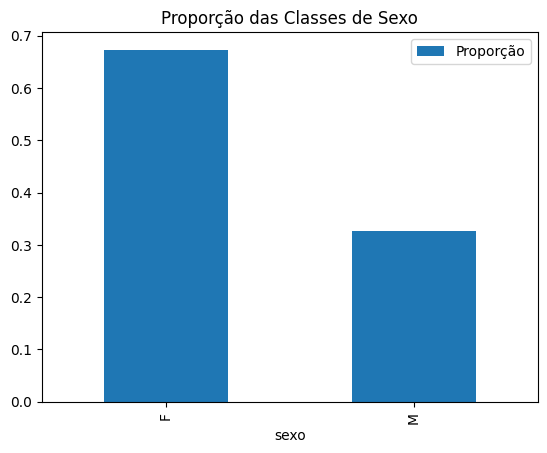

,Proporção
posse_de_veiculo,
N,0.610488
S,0.389512


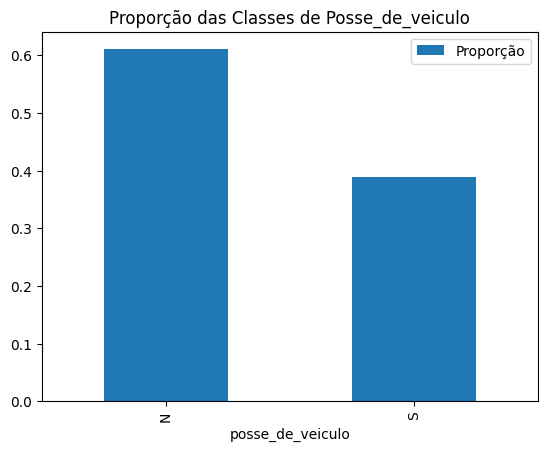

,Proporção
posse_de_imovel,
S,0.671757
N,0.328243


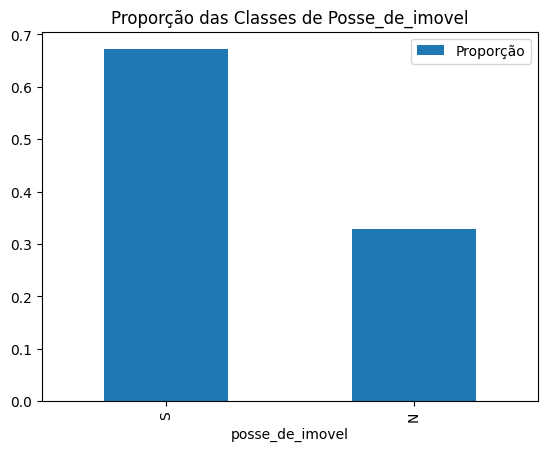

,qtd_filhos
contagem,600000.000000
média,0.433210
desvio padrão,0.739869
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,14.000000


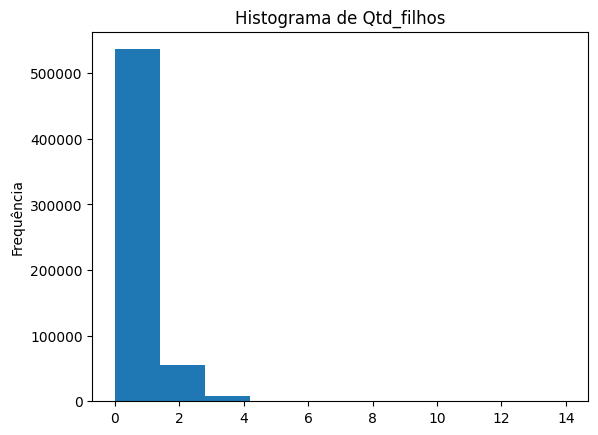

,Proporção
tipo_renda,
Assalariado,0.514100
Empresário,0.230235
Pensionista,0.168545
Servidor público,0.086635
Bolsista,0.000485


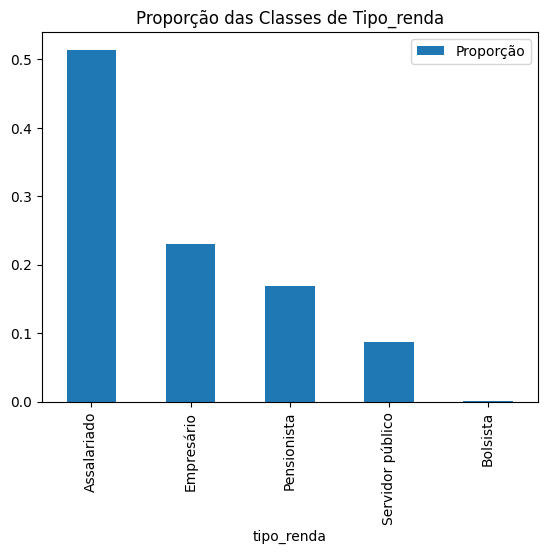

,Proporção
educacao,
Médio,0.675748
Superior completo,0.272400
Superior incompleto,0.039265
Fundamental,0.011502
Pós graduação,0.001085


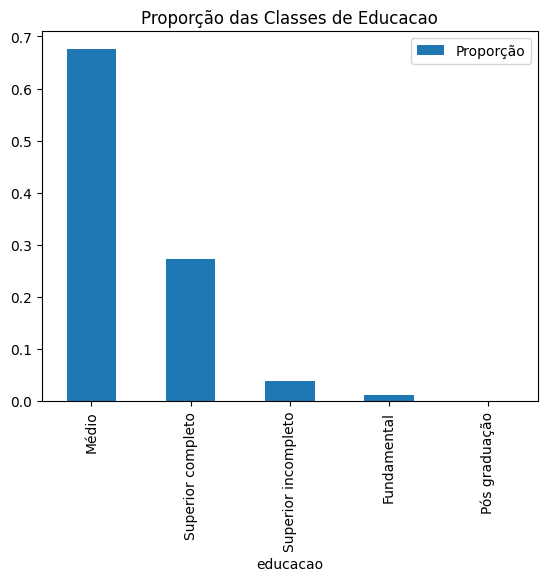

,Proporção
estado_civil,
Casado,0.701915
Solteiro,0.122035
União,0.076847
Separado,0.056980
Viúvo,0.042223


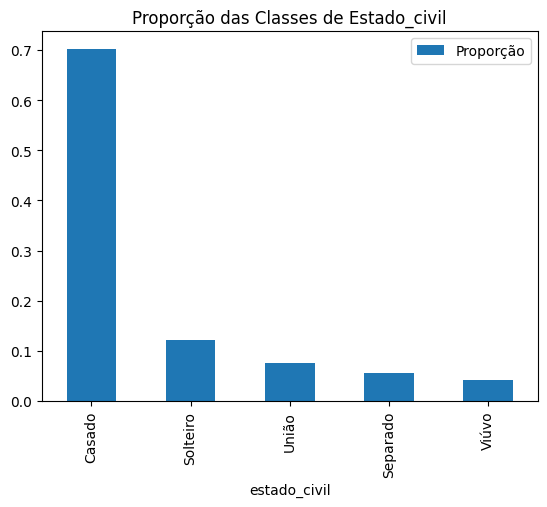

,Proporção
tipo_residencia,
Casa,0.898893
Com os pais,0.044550
Governamental,0.031237
Aluguel,0.013770
Estúdio,0.007160
Comunitário,0.004390


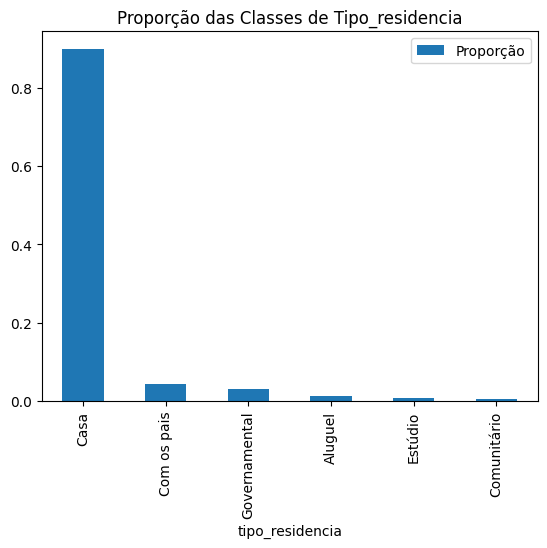

,idade
contagem,600000.000000
média,43.798530
desvio padrão,11.230659
min,22.000000
25%,34.000000
50%,43.000000
75%,53.000000
max,68.000000


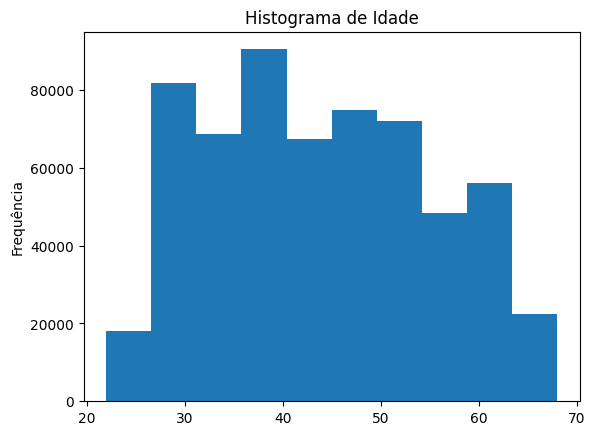

,tempo_emprego
contagem,499125.000000
média,7.747992
desvio padrão,6.688576
min,0.117808
25%,3.049315
50%,6.046575
75%,10.180822
max,42.906849


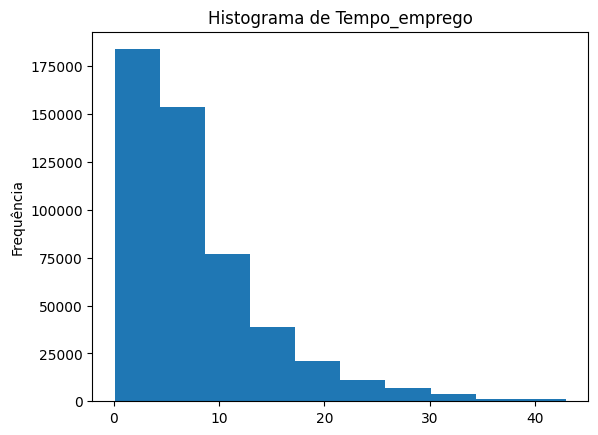

,qt_pessoas_residencia
contagem,600000.000000
média,2.212122
desvio padrão,0.903757
min,1.000000
25%,2.000000
50%,2.000000
75%,3.000000
max,15.000000


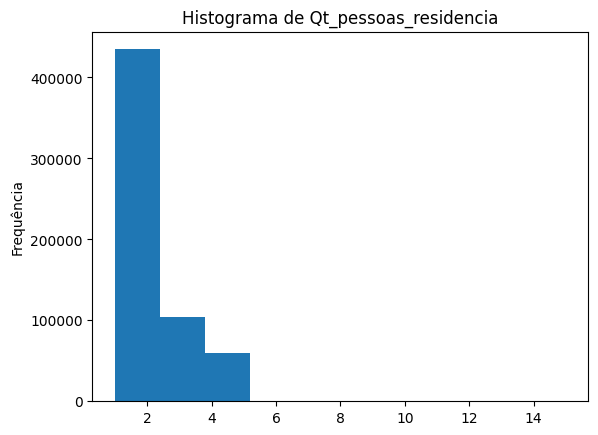

,renda
contagem,6.000000e+05
média,2.722284e+04
desvio padrão,8.737788e+04
min,1.618600e+02
25%,4.670600e+03
50%,9.887580e+03
75%,2.162887e+04
max,4.083986e+06


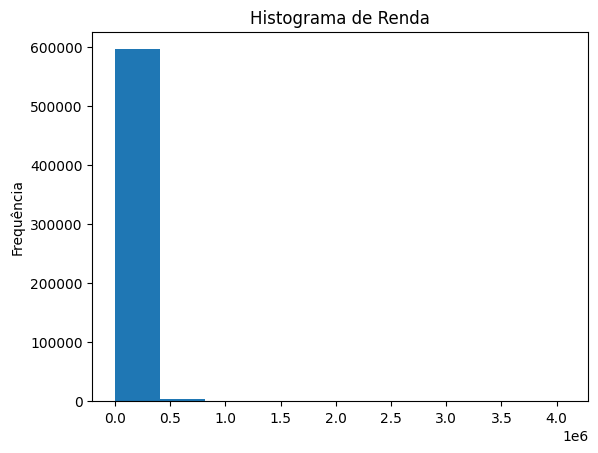

In [7]:
# Realizando análise univariada por cada variável na base de dados
for col in data:
    if metadata[metadata.index == col]['papel'].iloc[0] != 'independente':
        continue
    else:
        tipo =  metadata[metadata.index == col]['tipo_variavel'].iloc[0]
        analise_univariada(data[col], tipo)

## Descritiva bivariada

Faça uma análise descritiva bivariada de cada variável

In [ ]:
# Definindo funções para conduzir análise bivariada (independente x dependente) por cada variável na base de dados
def analise_bivariada_quantitativa(variavel_independente: pd.Series, variavel_dependente: pd.Series) -> None:
    pass

In [27]:
def melhor_categorizacao(variavel: pd.Series, max_quartis: int=10):
    '''
    Encontra a melhor categorização de uma variável contínua testando diferentes números de quantis.

    Parâmetros:
    - variavel: Series do Pandas contendo os valores contínuos.
    - max_quartis: número máximo de quantis a testar (default: 10).

    Retorna:
    - Melhor número de categorias encontrado.
    - Labels categorizados com base nos melhores quantis.
    '''
    
    dt = np.array(variavel).reshape(-1, 1)  
    best_q = None
    best_silhouette = -1
    best_labels = None

    for q in range(2, max_quartis + 1):
        try:
            labels = pd.qcut(dt.flatten(), q, labels=False, duplicates='drop')
            if len(set(labels)) < 2:  
                continue
            
            score = silhouette_score(dt, labels, sample_size=int(dt.shape[0] / 100), random_state=412)
            
            if score > best_silhouette:
                best_silhouette = score
                best_q = q
                best_labels = labels

        except Exception:
            continue 

    return best_q, best_labels

In [30]:
mc = melhor_categorizacao(data['qtd_filhos'])

In [36]:
mc[1]

array([0, 0, 1, ..., 0, 0, 0], dtype=int64)

## Desenvolvimento do modelo

Desenvolva um modelo de *credit scoring* através de uma regressão logística.

- Trate valores missings e outliers
- Trate 'zeros estruturais'
- Faça agrupamentos de categorias conforme vimos em aula
- Proponha uma equação preditiva para 'mau'
- Caso hajam categorias não significantes, justifique

## Avaliação do modelo

Avalie o poder discriminante do modelo pelo menos avaliando acurácia, KS e Gini.

Avalie estas métricas nas bases de desenvolvimento e *out of time*.

# a - Criar um pipeline utilizando o sklearn pipeline para o preprocessamento 

## Pré processamento

### Substituição de nulos (nans)

Existe nulos na base? é dado numérico ou categórico? qual o valor de substituição? média? valor mais frequente? etc

### Remoção de outliers

Como identificar outlier? Substituir o outlier por algum valor? Remover a linha?

### Seleção de variáveis

Qual tipo de técnica? Boruta? Feature importance? 

### Redução de dimensionalidade (PCA)

Aplicar PCA para reduzir a dimensionalidade para 5

### Criação de dummies

Aplicar o get_dummies() ou onehotencoder() para transformar colunas catégoricas do dataframe em colunas de 0 e 1. 
- sexo
- posse_de_veiculo
- posse_de_imovel
- tipo_renda
- educacao
- estado_civil
- tipo_residencia

### Pipeline 

Crie um pipeline contendo essas funções.

preprocessamento()
- substituicao de nulos
- remoção outliers
- PCA
- Criação de dummy de pelo menos 1 variável (posse_de_veiculo)

# b - Pycaret na base de dados 

Utilize o pycaret para pre processar os dados e rodar o modelo **lightgbm**. Faça todos os passos a passos da aula e gere os gráficos finais. E o pipeline de toda a transformação.



In [4]:
import pandas as pd

df = pd.read_feather('credit_scoring.ftr')
df.head()

,data_ref,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda,mau
0,2015-01-01,5733,F,N,N,0,Empresário,Médio,Solteiro,Casa,43,6.873973,1.0,2515.39,False
1,2015-01-01,727,F,S,S,0,Assalariado,Médio,Casado,Casa,35,4.526027,2.0,3180.19,False
2,2015-01-01,6374,F,N,N,2,Assalariado,Médio,Casado,Casa,31,0.243836,4.0,1582.29,False
3,2015-01-01,9566,F,N,N,0,Assalariado,Médio,Casado,Casa,54,12.772603,2.0,13721.17,False
4,2015-01-01,9502,F,S,N,0,Assalariado,Superior incompleto,Solteiro,Casa,31,8.432877,1.0,2891.08,False


In [ ]:
from pycaret.classification import *
models()

In [ ]:
xxx = create_model('xxx')